In [ ]:
# codigo inicial que unificou as bases de vendas e vistoria, criou as colunas de ágio absoluto e percentual, 
# e removeu os registros duplicados dos itens agrupados

# import pandas as pd
# pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# tabela = pd.read_csv("Vendas_NOVO_AREAS.csv", sep=";", encoding="latin-1")
# vistoria = pd.read_csv("Vistoria.csv", sep=";", encoding="latin-1")

# tabela = tabela.merge(
#     vistoria[["CD_IMOVEL_URBANO", "SIM_SITIMO_DS"]],
#     how="left",
#     left_on="CD_IMOVEL",
#     right_on="CD_IMOVEL_URBANO"
# )

# # remove a coluna duplicada da chave
# tabela = tabela.drop(columns=["CD_IMOVEL_URBANO"])
# tabela = tabela.rename(columns={"SIM_SITIMO_DS": "SITUACAO_VISTORIA"})
# tabela["SITUACAO_VISTORIA"] = tabela["SITUACAO_VISTORIA"].fillna("SEM_VISTORIA")

# tabela = tabela.drop(columns=["CD_IMOVEL"])



# #criacao da coluna AGIO ABSOLUTO , esta coluna deve ser retirada do treino
# tabela["AGIO_ABSOLUTO"] = tabela["VALOR_VENDA"] - tabela["VALOR_LAUDO"]
# tabela["AGIO_PERCENTUAL"] = ((tabela["VALOR_VENDA"] - tabela["VALOR_LAUDO"]) / tabela["VALOR_LAUDO"]) * 100

# tabela
# tabela.to_csv('dados.csv', sep=";", index=False, encoding='utf-8')
# tabela.describe()


FileNotFoundError: [Errno 2] No such file or directory: 'Vendas_Final.csv'

In [22]:
# leitura da base de dados já processada, com as colunas de ágio absoluto e percentual, e sem os registros duplicados dos itens agrupados
import pandas as pd
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

tabela = pd.read_csv("dados.csv", sep=";", encoding="latin-1")

In [20]:
# Análises estatísticas descritivas para as colunas numéricas:

# 1) Valores máximos, mínimos, médias e desvios padrão

print(f"Maior área de imóvel (em m²): {tabela['AREA'].max():.2f}")
print(f"Menor área de imóvel (em m²): {tabela['AREA'].min():.2f}")
print(f"Média área de imóvel (em m²): {tabela['AREA'].mean():.2f}")
print(f"Desvio Padrão área de imóvel (em m²): {tabela['AREA'].std():.2f}")

print(f"Maior Valor de Avaliaçao: {tabela['VALOR_LAUDO'].max():.2f}")
print(f"Menor Valor de Avaliação: {tabela['VALOR_LAUDO'].min():.2f}")
print(f"Média do Valor da Avaliação: {tabela['VALOR_LAUDO'].mean():.2f}")
print(f"Desvio Padrão do Valor da Avaliação: {tabela['VALOR_LAUDO'].std():.2f}")

print(f"Maior Valor de Venda: {tabela['VALOR_VENDA'].max():.2f}")
print(f"Menor Valor de Venda: {tabela['VALOR_VENDA'].min():.2f}")
print(f"Média do Valor da Venda: {tabela['VALOR_VENDA'].mean():.2f}")
print(f"Desvio Padrão do Valor da Venda: {tabela['VALOR_VENDA'].std():.2f}")

print(f"Maior Qtd de Ofertas: {tabela['QTD_OFERTAS'].max():.2f}")
print(f"Menor Qtd de Ofertas: {tabela['QTD_OFERTAS'].min():.2f}")
print(f"Média da Qtd de Ofertas: {tabela['QTD_OFERTAS'].mean():.2f}")
print(f"Desvio Padrão da Qtd de Ofertas: {tabela['QTD_OFERTAS'].std():.2f}")

agio_medio_abs = tabela["AGIO_ABSOLUTO"].mean()
agio_medio_pct = tabela["AGIO_PERCENTUAL"].mean()
print(f"Ágio médio absoluto: {agio_medio_abs:,.2f}")
print(f"Ágio médio percentual: {agio_medio_pct:.2f}%") 

# 2) Medianas
mediana_area = tabela["AREA"].median()
mediana_valor_laudо = tabela["VALOR_LAUDO"].median()
mediana_valor_venda = tabela["VALOR_VENDA"].median()
agio_mediano_abs = tabela["AGIO_ABSOLUTO"].median()
agio_mediano_pct = tabela["AGIO_PERCENTUAL"].median()

print(f"Mediana da Área do Imóvel (em m2): {mediana_area:,.2f}")
print(f"Mediana do Valor de Avaliação: {mediana_valor_laudо:,.2f}")
print(f"Mediana do Valor de Venda: {mediana_valor_venda:,.2f}")
print(f"Ágio mediano absoluto: {agio_mediano_abs:,.2f}")
print(f"Ágio mediano percentual: {agio_mediano_pct:.2f}%")

# 3) Quartis
quartis_area = tabela["AREA"].quantile([0.25, 0.50, 0.75])
quartis_valor_laudo = tabela["VALOR_LAUDO"].quantile([0.25, 0.50, 0.75])
quartis_valor_venda = tabela["VALOR_VENDA"].quantile([0.25, 0.50, 0.75])
quartis_agio_percentual = tabela["AGIO_PERCENTUAL"].quantile([0.25, 0.50, 0.75])
quartis_agio_absoluto = tabela["AGIO_ABSOLUTO"].quantile([0.25, 0.50, 0.75])

print(f"Quartis da Área do Imóvel (em m2): {quartis_area}")
print(f"Quartis do Valor de Avaliação: {quartis_valor_laudo}")
print(f"Quartis do Valor de Venda: {quartis_valor_venda}")
print(f"Quartis do Ágio Percentual: {quartis_agio_percentual}")
print(f"Quartis do Ágio Absoluto: {quartis_agio_absoluto}")

# 4) Coeficiente de variação = (desvio padrão / média) * 100
cv_area = (tabela["AREA"].std() / tabela["AREA"].mean()) * 100
cv_valor_laudo = (tabela["VALOR_LAUDO"].std() / tabela["VALOR_LAUDO"].mean()) * 100
cv_valor_venda = (tabela["VALOR_VENDA"].std() / tabela["VALOR_VENDA"].mean()) * 100
cv_qtd_ofertas = (tabela["QTD_OFERTAS"].std() / tabela["QTD_OFERTAS"].mean()) * 100
cv_agio_absoluto = (tabela["AGIO_ABSOLUTO"].std() / tabela["AGIO_ABSOLUTO"].mean()) * 100
cv_agio_percentual = (tabela["AGIO_PERCENTUAL"].std() / tabela["AGIO_PERCENTUAL"].mean()) * 100

print(cv_area, cv_valor_laudo, cv_valor_venda, cv_qtd_ofertas, cv_agio_absoluto, cv_agio_percentual)



Maior área de imóvel (em m²): 164084.00
Menor área de imóvel (em m²): 4.00
Média área de imóvel (em m²): 710.89
Desvio Padrão área de imóvel (em m²): 3889.23
Maior Valor de Avaliaçao: 353000000.00
Menor Valor de Avaliação: 2412.00
Média do Valor da Avaliação: 978713.85
Desvio Padrão do Valor da Avaliação: 7056496.58
Maior Valor de Venda: 406670000.00
Menor Valor de Venda: 3800.00
Média do Valor da Venda: 1247612.42
Desvio Padrão do Valor da Venda: 8323860.91
Maior Qtd de Ofertas: 52.00
Menor Qtd de Ofertas: 1.00
Média da Qtd de Ofertas: 3.12
Desvio Padrão da Qtd de Ofertas: 4.06
Mediana da Área do Imóvel (em m2): 287.50
Mediana do Valor de Avaliação: 284,500.00
Mediana do Valor de Venda: 329,850.00
Ágio mediano absoluto: 33,999.50
Ágio mediano percentual: 14.92%
Quartis da Área do Imóvel (em m2): 0.25   105.00
0.50   287.50
0.75   700.00
Name: AREA, dtype: float64
Quartis do Valor de Avaliação: 0.25   127042.50
0.50   284500.00
0.75   493750.00
Name: VALOR_LAUDO, dtype: float64
Quartis

In [25]:
# lista das colunas que você quer analisar
colunas = [
    "VALOR_LAUDO",
    "AREA_MAX_CONSTR",
    "AREA_BASE",
    "AREA",
    "QTD_OFERTAS",
    "AGIO_ABSOLUTO",
    "AGIO_PERCENTUAL",
    "VALOR_VENDA"   # target Y
]

# cria um dataframe apenas com essas colunas
df_corr = tabela[colunas].copy()

# calcula a matriz de correlação
matriz_corr = df_corr.corr(method="pearson")
# correlação de todas as variáveis com a target
corr_com_y = matriz_corr["VALOR_VENDA"].sort_values(ascending=False)


                 VALOR_LAUDO  AREA_MAX_CONSTR  AREA_BASE  AREA  QTD_OFERTAS  \
VALOR_LAUDO             1.00             0.86       0.95  0.84        -0.01   
AREA_MAX_CONSTR         0.86             1.00       0.95  0.95        -0.03   
AREA_BASE               0.95             0.95       1.00  0.95        -0.02   
AREA                    0.84             0.95       0.95  1.00        -0.02   
QTD_OFERTAS            -0.01            -0.03      -0.02 -0.02         1.00   
AGIO_ABSOLUTO           0.79             0.67       0.74  0.69         0.09   
AGIO_PERCENTUAL        -0.01             0.00       0.00  0.01         0.46   
VALOR_VENDA             0.99             0.85       0.94  0.84         0.01   

                 AGIO_ABSOLUTO  AGIO_PERCENTUAL  VALOR_VENDA  
VALOR_LAUDO               0.79            -0.01         0.99  
AREA_MAX_CONSTR           0.67             0.00         0.85  
AREA_BASE                 0.74             0.00         0.94  
AREA                      0.69      

In [24]:
import pandas as pd

dados_corr = {
    "VALOR_LAUDO":       [1.00, 0.86, 0.95, 0.84, -0.01, 0.79, -0.01, 0.99],
    "AREA_MAX_CONSTR":   [0.86, 1.00, 0.95, 0.95, -0.03, 0.67,  0.00, 0.85],
    "AREA_BASE":         [0.95, 0.95, 1.00, 0.95, -0.02, 0.74,  0.00, 0.94],
    "AREA":              [0.84, 0.95, 0.95, 1.00, -0.02, 0.69,  0.01, 0.84],
    "QTD_OFERTAS":       [-0.01, -0.03, -0.02, -0.02, 1.00, 0.09, 0.46, 0.01],
    "AGIO_ABSOLUTO":     [0.79, 0.67, 0.74, 0.69, 0.09, 1.00, 0.20, 0.86],
    "AGIO_PERCENTUAL":   [-0.01, 0.00, 0.00, 0.01, 0.46, 0.20, 1.00, 0.03],
    "VALOR_VENDA":       [0.99, 0.85, 0.94, 0.84, 0.01, 0.86, 0.03, 1.00]
}

indice = [
    "VALOR_LAUDO",
    "AREA_MAX_CONSTR",
    "AREA_BASE",
    "AREA",
    "QTD_OFERTAS",
    "AGIO_ABSOLUTO",
    "AGIO_PERCENTUAL",
    "VALOR_VENDA"
]

tabela_corr = pd.DataFrame(dados_corr, index=indice)

tabela_corr

,VALOR_LAUDO,AREA_MAX_CONSTR,AREA_BASE,AREA,QTD_OFERTAS,AGIO_ABSOLUTO,AGIO_PERCENTUAL,VALOR_VENDA
VALOR_LAUDO,1.00,0.86,0.95,0.84,-0.01,0.79,-0.01,0.99
AREA_MAX_CONSTR,0.86,1.00,0.95,0.95,-0.03,0.67,0.00,0.85
AREA_BASE,0.95,0.95,1.00,0.95,-0.02,0.74,0.00,0.94
AREA,0.84,0.95,0.95,1.00,-0.02,0.69,0.01,0.84
QTD_OFERTAS,-0.01,-0.03,-0.02,-0.02,1.00,0.09,0.46,0.01
AGIO_ABSOLUTO,0.79,0.67,0.74,0.69,0.09,1.00,0.20,0.86
AGIO_PERCENTUAL,-0.01,0.00,0.00,0.01,0.46,0.20,1.00,0.03
VALOR_VENDA,0.99,0.85,0.94,0.84,0.01,0.86,0.03,1.00


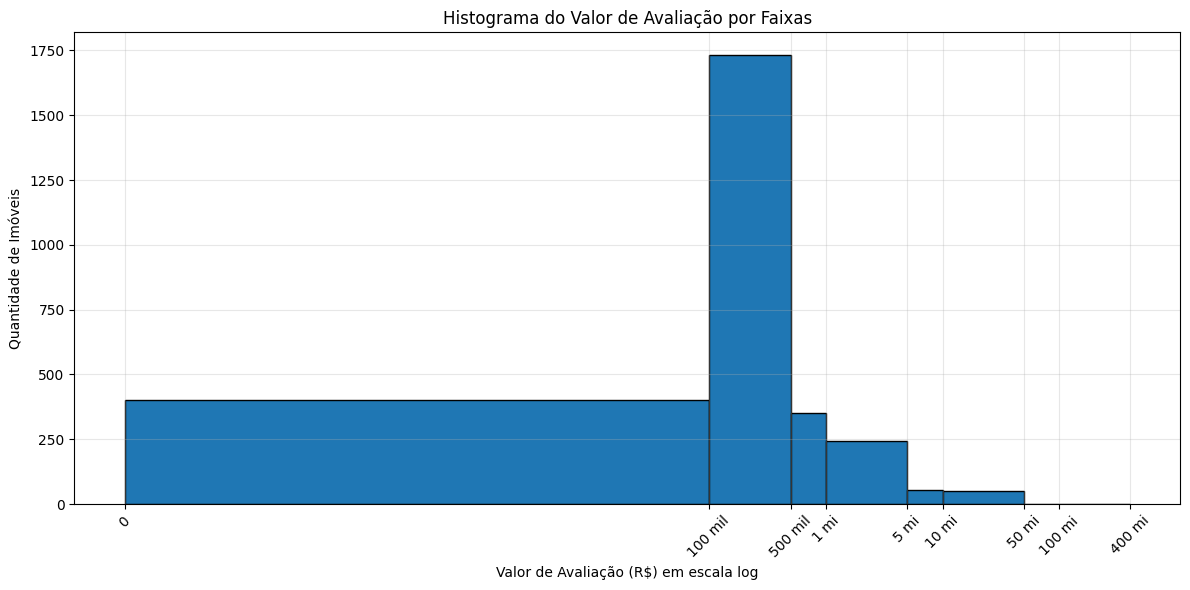

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# faixas no valor original
faixas_valor = [
    0,
    100_000,
    500_000,
    1_000_000,
    5_000_000,
    10_000_000,
    50_000_000,
    100_000_000,
    400_000_000
]

# converter as faixas para escala log
faixas_log = np.log1p(faixas_valor)

# dados transformados em log
dados_log = np.log1p(tabela["VALOR_LAUDO"].dropna())

plt.figure(figsize=(12, 6))
plt.hist(dados_log, bins=faixas_log, edgecolor="black")

plt.title("Histograma do Valor de Avaliação por Faixas")
plt.xlabel("Valor de Avaliação (R$) em escala log")
plt.ylabel("Quantidade de Imóveis")
plt.grid(True, alpha=0.3)

# mostrar no eixo X os valores originais, não o log
plt.xticks(
    faixas_log,
    [
        "0",
        "100 mil",
        "500 mil",
        "1 mi",
        "5 mi",
        "10 mi",
        "50 mi",
        "100 mi",
        "400 mi"
    ],
    rotation=45
)

plt.tight_layout()
plt.show()

In [29]:
# y -> é a coluna da base de dados que eu quero prever
y = tabela["VALOR_VENDA"]

# x -> as colunas da base de dados que eu vou usar pra fazer a previsão
X = tabela.drop(columns=["VALOR_VENDA", "AGIO_ABSOLUTO", "AGIO_PERCENTUAL"])


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# identificar tipos de colunas
num_cols = X_treino.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_treino.columns if c not in num_cols]

# preprocessamento
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

# modelos de REGRESSÃO
modelo_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

modelo_knn = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsRegressor(n_neighbors=10))
])

# treinar
modelo_rf.fit(X_treino, y_treino)
modelo_knn.fit(X_treino, y_treino)

# avaliar
def avaliar(nome, modelo):
    pred = modelo.predict(X_teste)
    mae = mean_absolute_error(y_teste, pred)
    rmse = root_mean_squared_error(y_teste, pred)
    r2 = r2_score(y_teste, pred)
    print(f"\n== {nome} ==")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)

avaliar("RandomForestRegressor", modelo_rf)
avaliar("KNeighborsRegressor", modelo_knn)


== RandomForestRegressor ==
MAE: 152858.48309136266
RMSE: 635944.5738052719
R²: 0.9645852188023477

== KNeighborsRegressor ==
MAE: 220987.2262934272
RMSE: 897687.2915236248
R²: 0.9294338887960294


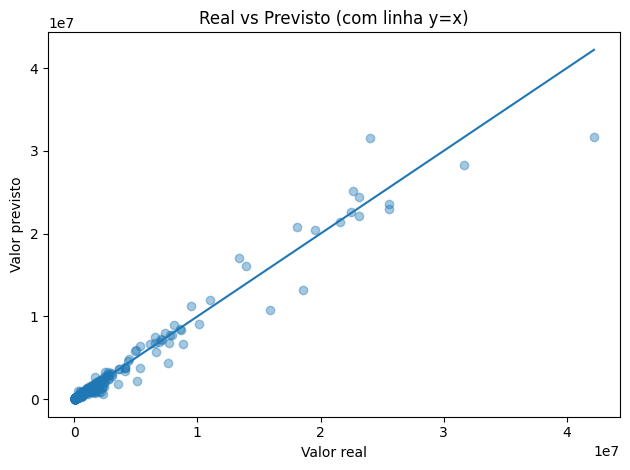

In [31]:
import matplotlib.pyplot as plt
# from cycler import cycler

# cores = plt.get_cmap('tab20b').colors
# ciclo_cores = cycler('color', cores)
# plt.rc('axes', prop_cycle=ciclo_cores)

y_pred = modelo_rf.predict(X_teste)

plt.figure()
plt.scatter(y_teste, y_pred, alpha=0.4)

mx = max(y_teste.max(), y_pred.max())
plt.plot([0, mx], [0, mx])  # linha y = x (perfeito)

plt.title("Real vs Previsto (com linha y=x)")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.tight_layout()
plt.show()

In [32]:
import numpy as np

# previsões do modelo no conjunto de teste
y_pred = modelo_rf.predict(X_teste)

# dataframe comparativo: traz as linhas originais do teste
comparacao = tabela.loc[X_teste.index].copy()

comparacao = comparacao.drop(columns=["COD_DESTINACAO_IMOVEL", "EDITAL_VENDA", "ITEM_EDITAL", "VALOR_VENDA", "AREA_MAX_CONSTR", "AREA_BASE", "AREA"])  # remove a coluna de valor real para evitar confusão

# adiciona colunas de comparação
comparacao["VALOR_REAL"] = y_teste
comparacao["VALOR_PREVISTO"] = y_pred
comparacao["ERRO"] = comparacao["VALOR_REAL"] - comparacao["VALOR_PREVISTO"]
comparacao["ERRO_ABS"] = comparacao["ERRO"].abs()
comparacao["ERRO_PCT"] = ((comparacao["ERRO_ABS"] / comparacao["VALOR_REAL"]) * 100).round(2)
comparacao["ERRO_PCT"] = comparacao["ERRO_PCT"].map(lambda x: f"{x:.2f}%")


# ver as piores previsões (maior erro absoluto)
comparacao.sort_values("ERRO_ABS", ascending=False).head(50)

,SETOR,CIDADE,ANO_VENDA,VALOR_LAUDO,QTD_OFERTAS,SITUACAO_VISTORIA,AGIO_ABSOLUTO,AGIO_PERCENTUAL,VALOR_REAL,VALOR_PREVISTO,ERRO,ERRO_ABS,ERRO_PCT
218,BAIRRO AGUAS CLARAS,TAGUATINGA,2020,33700000,3,OBSTRUIDO,8500000.00,25.22,42200000.00,31685822.75,10514177.25,10514177.25,24.92%
831,POLO DESENV/ECONOMICO JUSCELINO KUBITSCHEK IND...,SANTA MARIA,2021,23700000,1,VAGO,300003.50,1.27,24000003.50,31592433.14,-7592429.64,7592429.64,31.64%
979,BAIRRO AGUAS CLARAS,TAGUATINGA,2022,11800000,3,VAGO,6811000.00,57.72,18611000.00,13191980.53,5419019.47,5419019.47,29.12%
1596,BAIRRO AGUAS CLARAS,TAGUATINGA,2023,8350000,2,VAGO,7543000.00,90.34,15893000.00,10778088.32,5114911.68,5114911.68,32.18%
220,SETOR DE CLUBES ESPORTIVOS SUL,BRASILIA,2020,13400000,1,VAGO,12000.00,0.09,13412000.00,17115536.18,-3703536.18,3703536.18,27.61%
838,SHCNW-SETOR DE HABITAÃÃES COLETIVAS NOROESTE,BRASILIA,2021,19000000,4,VAGO,12652000.00,66.59,31652000.00,28231307.54,3420692.46,3420692.46,10.81%
1366,SETOR DE HABITACOES INDIVIDUAIS SUL,BRASILIA,2023,2140000,22,VAGO,5460000.00,255.14,7600000.00,4395393.66,3204606.34,3204606.34,42.17%
2102,SETOR O NORTE-QUADRA RESIDENCIAL,CEILANDIA,2024,1310000,9,OCUPADO,3790000.00,289.31,5100000.00,2174291.18,2925708.82,2925708.82,57.37%
759,SETOR DE INDUSTRIA E ABASTECIMENTO,BRASILIA,2021,16651000,1,OCUPADO,1450000.00,8.71,18101000.00,20774671.65,-2673671.65,2673671.65,14.77%
433,SHCNW-SETOR DE HABITAÃÃES COLETIVAS NOROESTE,BRASILIA,2021,17300000,5,OBSTRUIDO,8225000.00,47.54,25525000.00,22937032.92,2587967.08,2587967.08,10.14%


In [33]:
# maiores acertos (menor erro absoluto)
comparacao.sort_values("ERRO_ABS", ascending=True).head(50)

,SETOR,CIDADE,ANO_VENDA,VALOR_LAUDO,QTD_OFERTAS,SITUACAO_VISTORIA,AGIO_ABSOLUTO,AGIO_PERCENTUAL,VALOR_REAL,VALOR_PREVISTO,ERRO,ERRO_ABS,ERRO_PCT
2547,COMP. URB. ALDEIAS DO CERRADO - QR 04 - RESIDE...,JARDIM BOTÃNICO,2025,317000,1,VAGO,1200.00,0.38,318200.00,318202.91,-2.91,2.91,0.00%
1926,SETOR RESID INDUSTRIA E ABASTECIMENTO,GUARA,2024,308000,4,VAGO,124014.77,40.26,432014.77,432021.97,-7.20,7.20,0.00%
2599,RECANTO DAS EMAS,RECANTO DAS EMAS,2025,146000,1,VAGO,5000.00,3.42,151000.00,150913.81,86.19,86.19,0.06%
1575,COMP. URB. ALDEIAS DO CERRADO - QR 02 - RESIDE...,JARDIM BOTÃNICO,2023,304000,1,VAGO,4389.00,1.44,308389.00,308187.68,201.32,201.32,0.07%
2110,COMP. URB. ALDEIAS DO CERRADO - QR 02 - RESIDE...,JARDIM BOTÃNICO,2024,301000,2,VAGO,11001.00,3.65,312001.00,312209.85,-208.85,208.85,0.07%
1945,QS-SAMAMBAIA,SAMAMBAIA,2024,121000,1,VAGO,16000.00,13.22,137000.00,137240.22,-240.22,240.22,0.18%
1426,RECANTO DAS EMAS,RECANTO DAS EMAS,2023,132000,1,VAGO,1000.00,0.76,133000.00,132759.26,240.74,240.74,0.18%
1100,QS-SAMAMBAIA,SAMAMBAIA,2022,69800,1,OBSTRUIDO,8700.00,12.46,78500.00,78251.44,248.56,248.56,0.32%
2580,QS-SAMAMBAIA,SAMAMBAIA,2025,216000,1,VAGO,47013.00,21.77,263013.00,262761.67,251.33,251.33,0.10%
2459,QS-SAMAMBAIA,SAMAMBAIA,2025,121000,2,VAGO,34555.55,28.56,155555.55,155250.29,305.26,305.26,0.20%


In [34]:
# avaliar o impacto do laudo na previsão (comparar com e sem a coluna de laudo)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def avaliar_modelo(df, drop_cols=None, random_state=42):
    drop_cols = drop_cols or []

    # y e X
    y = df["VALOR_VENDA"]
    X = df.drop(columns=["VALOR_VENDA"] + drop_cols)

    # split
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X, y, test_size=0.3, random_state=random_state
    )

    # detectar colunas por tipo (depois do drop)
    num_cols = X_treino.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X_treino.columns if c not in num_cols]

    # preprocess (recriado a cada chamada)
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ],
        remainder="drop"
    )

    # modelo
    modelo = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    # treinar / prever
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    # métricas
    mae = mean_absolute_error(y_teste, pred)
    rmse = root_mean_squared_error(y_teste, pred)
    r2 = r2_score(y_teste, pred)

    return mae, rmse, r2

# A) com laudo
mae_a, rmse_a, r2_a = avaliar_modelo(tabela, drop_cols=["AGIO_ABSOLUTO", "AGIO_PERCENTUAL"])
print("COM LAUDO  -> MAE:", mae_a, "| RMSE:", rmse_a, "| R²:", r2_a)

# B) sem laudo (ajuste o nome se necessário)
mae_b, rmse_b, r2_b = avaliar_modelo(tabela, drop_cols=["VALOR_LAUDO", "AGIO_ABSOLUTO", "AGIO_PERCENTUAL"])
print("SEM LAUDO  -> MAE:", mae_b, "| RMSE:", rmse_b, "| R²:", r2_b)

COM LAUDO  -> MAE: 152858.48309136266 | RMSE: 635944.5738052719 | R²: 0.9645852188023477
SEM LAUDO  -> MAE: 351576.72070678073 | RMSE: 1711119.7130068375 | R²: 0.7436066126514898
